# Training from data: gradient descent, SGD and mini-batches

*Introduction to Control and Machine Learning · Part III: Machine learning · Notebook 10*

> **Central question.** *How do we minimize a loss that is an average over many samples, what do stochastic gradients buy, and what do they cost?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 65–80 min · DEEPER LOOK and RESEARCH WINDOW ≈ 20 min more |
| **Execution time** | about ten seconds |
| **Exercises** | 6 exercises, ≈ 90–140 min |
| **Prerequisites** | [notebook 06](06_variational_principles_gradient_flows.ipynb) (gradient descent, step-size threshold, Lipschitz gradients), [notebook 09](09_machine_learning_foundations_generalization.ipynb) (empirical risk, train / validation / test protocol); expectation and variance |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 252–277, 306–308 (see the Source map at the end) |
| **Notation** | `notation.md` §4: $F(w)=\frac1N\sum_if_i(w)$, per-sample losses $f_i$ (a local overload of $f$), learning rate $\eta_k$ (the slides' $\alpha_k$), stochastic gradient $g_k$, mini-batch $I_k$ of size $N_b$ (the slides' $b$), variance bound $\sigma_g^2$ (the slides' $\sigma^2$). $\lambda$ is a regularization weight |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–8 (finite sums, GD recap, SGD and its cost, mini-batch variance, the audited convergence theorem, the comparison laboratory, the noise floor, early stopping), Figures 1–4, Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §10 (complete proofs), Exercises 3–4.
> *Research-oriented:* the RESEARCH WINDOW §11 and the `ADVANCED` Exercises 5–6.

**Learning objectives.** After this notebook you should be able to

1. write a training problem as the minimization of a finite sum, and count the cost of its gradient in per-sample gradient evaluations;
2. state SGD with and without replacement, and prove that the stochastic gradient is unbiased;
3. compute the variance of a mini-batch gradient for both sampling conventions;
4. state the convergence theorem of SGD exactly as it is proved: what it assumes, and what it does and does not conclude;
5. compare GD, SGD and mini-batch fairly, by iterations *and* by gradient evaluations;
6. explain the noise floor of constant steps and the role of the Robbins–Monro conditions;
7. choose a stopping time on the validation set, and keep the test set out of that choice.

## Where are we?
`CORE`

> **Recap.** [Notebook 06](06_variational_principles_gradient_flows.ipynb): gradient descent $u_{k+1}=u_k-\eta\nabla J(u_k)$ is the explicit Euler scheme of the gradient flow. For a quadratic it converges iff $0<\eta<2/\lambda_{\max}$, and the number of steps grows with the condition number. [Notebook 09](09_machine_learning_foundations_generalization.ipynb): training minimizes the empirical risk $F$; the result is judged on a validation set, and reported once on a test set.

This notebook keeps the method of notebook 06 and changes the objective. A training loss is an **average over $N$ samples**, and $N$ can be very large. Computing $\nabla F$ exactly then becomes the dominant cost, and an old idea from stochastic approximation takes over: *estimate* the gradient from a few samples. Everything turns on one question: what does the randomness of the estimate cost, and what does it buy?

## 1. Training as the minimization of a finite sum
`CORE`

The slides formulate training as (pp. 252–253)
$$
\min_{w\in\mathbb R^D}F(w),\qquad F(w)=\frac1N\sum_{i=1}^Nf_i(w),
$$
where $f_i(w)=\ell(\hat y(x_i;w),y_i)$ is the loss on the $i$-th training sample. Two examples (pp. 254–255): *linear regression*, $f_i(w)=(w\cdot(x_i;1)-y_i)^2$, and *logistic regression* for labels $y_i\in\{0,1\}$,
$$
f_i(w)=-y_i\,\phi_i\cdot w+\log\big(1+e^{\phi_i\cdot w}\big),\qquad \phi_i=(x_i;1).
$$
Its gradient is $\nabla f_i(w)=\big(s(\phi_i\cdot w)-y_i\big)\phi_i$, with the sigmoid $s(z)=1/(1+e^{-z})$.

**The laboratory problem.** Throughout §§4–7 we train a regularized logistic regression on the E6 half-moons, with the fixed split of notebook 09 (72 training samples) and the per-sample losses
$$
f_i(w)=-y_i\,\phi_i\cdot w+\log\big(1+e^{\phi_i\cdot w}\big)+\tfrac\lambda2|w|^2,\qquad\lambda=10^{-2},
$$
the problem the slides use for their own comparison (p. 277). Its Hessian is $\frac1N\sum_is'(\phi_i\cdot w)\phi_i\phi_i^\top+\lambda I$ with $0<s'\le\frac14$. So $F$ is $\lambda$-strongly convex and its gradient is $L$-Lipschitz with
$$
L\le\tfrac14\lambda_{\max}\Big(\tfrac1N\textstyle\sum_i\phi_i\phi_i^\top\Big)+\lambda .
$$
It therefore has a unique minimizer $w^*$. We compute it once to machine precision by Newton's method, only to measure errors $F(w_k)-F^*$. For neural networks, by contrast, $F$ is not convex (p. 257; notebook 09, §7), and the guarantees below are about stationary points, not minimizers.

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt

from src.ml_utils import (point_cloud_E6, split_indices, regression_E9, gaussian_features, polynomial_features, mean_squared_error,
                          logistic_features, logistic_loss, logistic_sample_gradients, logistic_batch_gradient, accuracy)
from src.optimization_utils import minibatch_sgd
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=4, suppress=True)

rng = np.random.default_rng(seed=0)          # the only source of randomness in this notebook (09-11 share it)
X6, y6 = point_cloud_E6(rng)                 # E6, as in notebooks 00 and 09
split6 = split_indices(len(y6), rng)         # the fixed E6 split of notebook 09
x9, y9 = regression_E9(rng)                  # E9 and its split, identical to notebook 09
split9 = split_indices(len(y9), rng)

In [2]:
train6, val6, test6 = split6
Phi_tr, y_tr6 = logistic_features(X6[train6]), y6[train6]
N, lam = len(y_tr6), 1e-2


def F(w):
    return logistic_loss(w, Phi_tr, y_tr6, lam)


def batch_grad(w, idx):
    # mean of grad f_i(w) over the index array idx
    return logistic_batch_gradient(w, Phi_tr, y_tr6, idx, lam)


L_bound = np.linalg.eigvalsh(Phi_tr.T @ Phi_tr / N)[-1] / 4 + lam      # Lipschitz constant of grad F (bound)

w_star = np.zeros(3)                                                    # reference minimizer by Newton's method
for _ in range(25):
    s = 0.5 * (1 + np.tanh(0.5 * Phi_tr @ w_star))
    hessian = (Phi_tr * (s * (1 - s))[:, None]).T @ Phi_tr / N + lam * np.eye(3)
    w_star = w_star - np.linalg.solve(hessian, batch_grad(w_star, np.arange(N)))
F_star = F(w_star)
G_star = logistic_sample_gradients(w_star, Phi_tr, y_tr6, lam)          # all per-sample gradients at w*
sigma2_star = np.mean(np.sum((G_star - G_star.mean(axis=0)) ** 2, axis=1))
print(f"N = {N} training samples, D = 3 parameters, L <= {L_bound:.4f}, strong convexity >= lambda = {lam}")
print(f"w* = {w_star},  F* = {F_star:.6f},  |grad F(w*)| = {np.linalg.norm(G_star.mean(axis=0)):.1e}")
print(f"variance of the per-sample gradients at w*: sigma^2(w*) = {sigma2_star:.4f}  (> 0: not an interpolating problem)")

N = 72 training samples, D = 3 parameters, L <= 0.3398, strong convexity >= lambda = 0.01
w* = [ 0.9755 -3.0065  0.0755],  F* = 0.358615,  |grad F(w*)| = 1.0e-17
variance of the per-sample gradients at w*: sigma^2(w*) = 0.1649  (> 0: not an interpolating problem)


## 2. Gradient descent, and what one step costs
`CORE`

Full-batch gradient descent (p. 262) is
$$
w_{k+1}=w_k-\eta_k\,\frac1N\sum_{i=1}^N\nabla f_i(w_k).
$$
It is the method of notebook 06 applied to $F$, and everything proved there applies: for an $L$-smooth, strongly convex $F$ it converges linearly when $\eta$ is small enough compared with $1/L$. We do not repeat that analysis.

What is new is the **cost of one step**. To compare methods honestly, we fix a unit.

> **Cost unit.** One **per-sample gradient evaluation** is one computation of $\nabla f_i(w)$ for one index $i$ at one point $w$. A GD step costs $N$ units, an SGD step $1$, a mini-batch step $N_b$.

This counts arithmetic on samples, not seconds. Wall-clock time also depends on memory traffic and on vectorization: computing $N_b$ gradients together on a GPU can take about as long as computing one, which is one reason mini-batches are popular (p. 275, "highly optimized matrix operations"). In this notebook every comparison uses the sample-gradient count, which does not depend on the machine. The slides list the challenges of GD for large $N$ (p. 263): each step is expensive, many samples carry redundant information, and the landscape may have bad local minima.

## 3. Stochastic gradient descent
`CORE`

**SGD (p. 264).** At step $k$, choose an index $i_k$ uniformly in $\{1,\dots,N\}$ and update
$$
w_{k+1}=w_k-\eta_k\,g_k,\qquad g_k=\nabla f_{i_k}(w_k).
$$
The slides distinguish two ways of drawing the indices (p. 264):

- **with replacement:** the $i_k$ are independent and uniform, independent of everything before step $k$;
- **without replacement:** the indices are taken in a shuffled order; $N$ consecutive steps visit every sample exactly once and form an **epoch**. The order is reshuffled at the start of each epoch.

**Unbiasedness.** With replacement, $i_k$ is independent of $w_k$, so conditionally on $w_k$
$$
\mathbb E\big[g_k\,\big|\,w_k\big]=\sum_{i=1}^N\frac1N\,\nabla f_i(w_k)=\nabla F(w_k).
$$
The stochastic gradient is an unbiased estimate of the full gradient (p. 264). This is the property every analysis below uses. Without replacement it holds for the first step of each epoch, but not for the later steps conditionally on the earlier ones (the visited samples cannot reappear). That is why the classical theory is stated for sampling with replacement.

Each SGD step costs one gradient evaluation instead of $N$. The price is noise: $g_k$ fluctuates around $\nabla F(w_k)$, and §5 shows that this noise prevents convergence unless the steps decrease.

## 4. Mini-batches and the variance of the stochastic gradient
`CORE`

**Mini-batch gradient descent (p. 275)** averages $N_b$ per-sample gradients:
$$
w_{k+1}=w_k-\eta_k\,\frac1{N_b}\sum_{i\in I_k}\nabla f_i(w_k),\qquad|I_k|=N_b .
$$
The slides note that it "reduces the variance of the updates". How much depends on the sampling convention. Fix $w$ and write
$$
\sigma^2(w)=\frac1N\sum_{i=1}^N\big|\nabla f_i(w)-\nabla F(w)\big|^2
$$
for the variance of one stochastic gradient (with replacement), and $g_B$ for the mini-batch mean.

> **Proposition 1 (variance of a mini-batch gradient).** *(A pedagogical addition; the slides give no formula.)*
> *With replacement* ($N_b$ independent uniform indices): $\mathbb E\,|g_B-\nabla F(w)|^2=\dfrac{\sigma^2(w)}{N_b}$.
> *Without replacement* ($I_k$ a uniformly chosen subset of size $N_b$): $\mathbb E\,|g_B-\nabla F(w)|^2=\dfrac{\sigma^2(w)}{N_b}\cdot\dfrac{N-N_b}{N-1}$.
> *Interpretation:* averaging $N_b$ independent estimates divides the variance by $N_b$; drawing without replacement removes even more, and gives zero variance for $N_b=N$, where the mini-batch is the full batch.

*Proof with replacement.* The terms $\nabla f_{i_j}(w)-\nabla F(w)$, $j=1,\dots,N_b$, are independent, have mean zero and second moment $\sigma^2(w)$; the second moment of their average is $\sigma^2(w)/N_b$. The case without replacement, the *finite-population correction* $(N-N_b)/(N-1)$, is proved in the DEEPER LOOK §10. $\square$

The cell below checks both formulas at $w^*$ by sampling 4000 mini-batches for each batch size.

N_b =  1:  with replacement 0.17140 (formula 0.16487);  without 0.16578 (formula 0.16487)
N_b =  2:  with replacement 0.08153 (formula 0.08243);  without 0.07921 (formula 0.08127)
N_b =  4:  with replacement 0.04218 (formula 0.04122);  without 0.03823 (formula 0.03948)
N_b =  8:  with replacement 0.02091 (formula 0.02061);  without 0.01828 (formula 0.01858)
N_b = 18:  with replacement 0.00904 (formula 0.00916);  without 0.00718 (formula 0.00697)
N_b = 36:  with replacement 0.00456 (formula 0.00458);  without 0.00232 (formula 0.00232)
N_b = 72:  with replacement 0.00235 (formula 0.00229);  without 0.00000 (formula 0.00000)


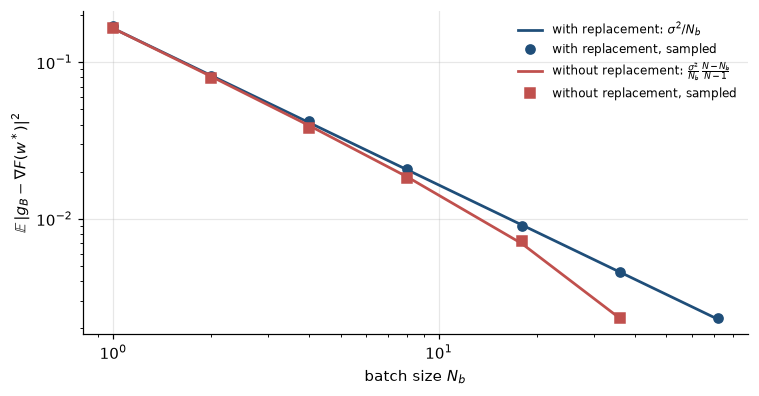

In [3]:
batch_sizes = np.array([1, 2, 4, 8, 18, 36, 72])
n_draws = 4000
var_with_mc, var_without_mc = [], []
for B in batch_sizes:
    with_rep = np.array([G_star[rng.integers(0, N, size=B)].mean(axis=0) for _ in range(n_draws)])
    without = np.array([G_star[rng.permutation(N)[:B]].mean(axis=0) for _ in range(n_draws)])
    var_with_mc.append(np.mean(np.sum((with_rep - G_star.mean(axis=0)) ** 2, axis=1)))
    var_without_mc.append(np.mean(np.sum((without - G_star.mean(axis=0)) ** 2, axis=1)))
var_with_formula = sigma2_star / batch_sizes
var_without_formula = sigma2_star / batch_sizes * (N - batch_sizes) / (N - 1)
for B, a, b, c, d in zip(batch_sizes, var_with_mc, var_with_formula, var_without_mc, var_without_formula):
    print(f"N_b = {B:2d}:  with replacement {a:.5f} (formula {b:.5f});  without {c:.5f} (formula {d:.5f})")

fig, ax = plt.subplots(figsize=(7.0, 3.7))
ax.loglog(batch_sizes, var_with_formula, "-", color=COLORS["state"], label=r"with replacement: $\sigma^2/N_b$")
ax.loglog(batch_sizes, var_with_mc, "o", color=COLORS["state"], label="with replacement, sampled")
ax.loglog(batch_sizes[:-1], var_without_formula[:-1], "-", color=COLORS["control"],
          label=r"without replacement: $\frac{\sigma^2}{N_b}\,\frac{N-N_b}{N-1}$")
ax.loglog(batch_sizes[:-1], np.array(var_without_mc)[:-1], "s", color=COLORS["control"], label="without replacement, sampled")
ax.set_xlabel("batch size $N_b$"); ax.set_ylabel(r"$\mathbb{E}\,|g_B-\nabla F(w^*)|^2$"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 1.** Variance of the mini-batch gradient of the E6 logistic problem at the minimizer $w^*$, against the batch size, for sampling with and without replacement: the formulas of Proposition 1 (lines) and averages over 4000 sampled batches (markers). The point $N_b=N=72$ without replacement, where the variance is exactly zero, cannot be drawn on a logarithmic axis.

*Interpretation.* The sampled variances follow the formulas. With replacement the variance falls like $1/N_b$, at every batch size. Without replacement it falls faster as $N_b$ approaches $N$ and vanishes at $N_b=N$. Note what the figure measures: the gradient is evaluated at $w^*$, where $\nabla F=0$, yet each single $\nabla f_i(w^*)$ is far from zero. **The stochastic gradient does not vanish at the minimizer.** This non-zero $\sigma^2(w^*)$ is the source of the noise floor of §7.

## 5. The convergence theorem of SGD, read exactly
`CORE`

The slides state a convergence result for SGD (p. 265) and prove it (pp. 266–268). Before using it, we transcribe it and check what the proof actually establishes.

**As printed on p. 265.** *Assumptions:* (1) $F(w)\ge F^*$ for all $w$; (2) $\nabla F$ is $L$-Lipschitz; (3) $\mathbb E[\|\nabla f_i(w^k)-\nabla F(w^k)\|^2]\le\sigma^2$; (4) $\alpha_k<2/L$. *Conclusions:* "the expected loss decays up to the noise level: $F(w^{k+1})\le F(w^k)+\alpha_k\sigma^2$"; and if $\sum_k\alpha_k=\infty$, $\sum_k\alpha_k^2<\infty$, then $\min_{k=1,\dots,K}\|\nabla F(w^k)\|^2\to0$ as $K\to\infty$.

**Audit.**

| Point | On the slide | What the proof (pp. 266–268) supports |
|---|---|---|
| sampling | $i$ uniform (p. 264) | $i_k$ uniform and independent of $w_1,\dots,w_k$: unbiasedness needs it |
| first conclusion | $F(w^{k+1})\le F(w^k)+\alpha_k\sigma^2$, no expectation | holds for the **conditional expectation** $\mathbb E[F(w_{k+1})\mid w_k]$; a single SGD step can increase $F$ by more |
| step size | $\alpha_k<2/L$ | the finite-$K$ bound needs $\alpha_k(1-\alpha_kL/2)\ge c\,\alpha_k$ with **one** $c>0$, i.e. $\sup_k\alpha_k<2/L$. Under the Robbins–Monro conditions this is automatic ($\alpha_k\to0$, and each of the finitely many earlier steps is $<2/L$); the explicit bound matters for other schedules, such as constant steps |
| second conclusion | $\min_k\|\nabla F(w^k)\|^2\to0$ | proved for $\min_k\mathbb E\|\nabla F(w_k)\|^2$ (hence for $\mathbb E\min_k\|\nabla F(w_k)\|^2$) via a weighted average of the $\mathbb E\|\nabla F(w_k)\|^2$; the statement here is in expectation, and says nothing about the last iterate |
| p. 268 | $F(\theta_1)$ | a misprint for $F(w^1)$ |

The statement below follows the proof; the hypotheses made explicit are marked.

> **Theorem 1 (SGD with Robbins–Monro steps; pp. 265–268, audited).**
> *Assumptions:* (A1) $F\ge F^*$; (A2) $\nabla F$ is $L$-Lipschitz; (A3) $\mathbb E\big[|\nabla f_{i_k}(w_k)-\nabla F(w_k)|^2\,\big|\,w_k\big]\le\sigma_g^2$ for every $k$; (A4) $0<\eta_k\le\bar\eta<2/L$ for all $k$ *(uniform bound made explicit; automatic under Robbins–Monro)*; (A5) $i_k$ uniform on $\{1,\dots,N\}$ and independent of $i_1,\dots,i_{k-1}$ *(made explicit)*; $w_1$ deterministic.
> *Conclusions:* with $c=1-\bar\eta L/2>0$,
> (i) $\mathbb E\big[F(w_{k+1})\,\big|\,w_k\big]\le F(w_k)-c\,\eta_k|\nabla F(w_k)|^2+\tfrac L2\eta_k^2\sigma_g^2\le F(w_k)+\eta_k\sigma_g^2$;
> (ii) for every $K$, with $S_K=\sum_{k=1}^K\eta_k$,
> $$\min_{1\le k\le K}\mathbb E\,|\nabla F(w_k)|^2\;\le\;\frac{1}{S_K}\sum_{k=1}^K\eta_k\,\mathbb E\,|\nabla F(w_k)|^2\;\le\;\frac{F(w_1)-F^*+\tfrac L2\sigma_g^2\sum_{k=1}^K\eta_k^2}{c\,S_K};$$
> (iii) if $\sum_k\eta_k=\infty$ and $\sum_k\eta_k^2<\infty$ (the **Robbins–Monro conditions**), the right-hand side of (ii) tends to $0$.
> *Interpretation:* SGD finds points with small expected squared gradient. If $F$ is moreover $\alpha$-strongly convex, $F(w)-F^*\le|\nabla F(w)|^2/(2\alpha)$ turns this into a bound on the expected optimality gap; without such an assumption the theorem says nothing quantitative about $F-F^*$, and for neural networks it concerns near-stationarity only.

The proof is three lines of algebra plus the unbiasedness of §3; it is written out in the DEEPER LOOK §10.

**Two consequences.**

- **Constant step: a bound that does not vanish.** With $\eta_k=\eta$ the weighted average in (ii) is the plain average, and $\frac1K\sum_{k\le K}\mathbb E|\nabla F(w_k)|^2\le\frac{F(w_1)-F^*}{c\,\eta K}+\frac{L\sigma_g^2}{2c}\,\eta$. The first term vanishes as $K\to\infty$; the second, **proportional to $\eta$**, does not. This is an *upper* bound: by itself it neither proves that the error stalls nor says where the iterates are. That a constant step does stall is proved exactly for a quadratic example in Exercise 2, where $\mathbb E(w_k-w^*)^2\to\eta s^2/(2-\eta)$, and observed in §7.
- **Why both conditions.** $\sum\eta_k=\infty$ lets the iterates travel arbitrarily far: the denominator grows. $\sum\eta_k^2<\infty$ makes the accumulated noise finite: the numerator stays bounded. A typical choice is $\eta_k=\eta_0/(1+k/k_0)$.

> **Remark on the source slides.** P. 271 compares the total work of GD, proportional to $N\log(1/\varepsilon)$, with that of SGD, proportional to $1/\varepsilon$. These are the classical rates for a **strongly convex** $F$ ($F(w_k)-F^*=O(\rho^k)$ for GD; $\mathbb E[F(w_k)-F^*]=O(1/k)$ for SGD with steps $\propto1/k$), with constants that depend on the condition number. The slide does not state these assumptions; we add them, and do not prove these rates. They are asymptotic statements, about the regime $\varepsilon\to0$ and $N$ large.

## 6. Laboratory: GD, SGD and mini-batch, compared fairly
`CORE`

All three methods minimize the *same* $F$ (same data, same $\lambda$), start from the *same* point $w=0$, and are run for the same budget of 40 epochs, that is, $40N$ per-sample gradient evaluations. The step sizes are fixed in advance from the bound $L$, not tuned on any data:

- **GD:** constant $\eta=1/L$, inside the range of notebook 06;
- **SGD** ($N_b=1$) and **mini-batch** ($N_b=8$), sampling with replacement: $\eta_k=\dfrac{1/L}{1+k\,N_b/N}$, which starts at $1/L$, whose denominator grows by one per epoch, and which satisfies the Robbins–Monro conditions and (A4).

We plot $F(w_k)-F^*$, averaged over 20 independent runs of each stochastic method, against the iteration count and against the gradient-evaluation count; shaded bands show the spread between runs.

> **Predict.** Which method is best per *iteration*? Which per *gradient evaluation* after one epoch? And after 40 epochs?

mean of F(w) - F* after [1, 2, 5, 10, 40] epochs (20 runs for the stochastic methods):
  GD                     [1.5e-01 8.5e-02 3.1e-02 1.0e-02 4.8e-05]
  SGD (N_b = 1)          [1.2e-01 7.1e-02 2.5e-02 1.0e-02 2.7e-03]
  mini-batch (N_b = 8)   [3.7e-02 1.5e-02 5.1e-03 2.7e-03 5.4e-04]


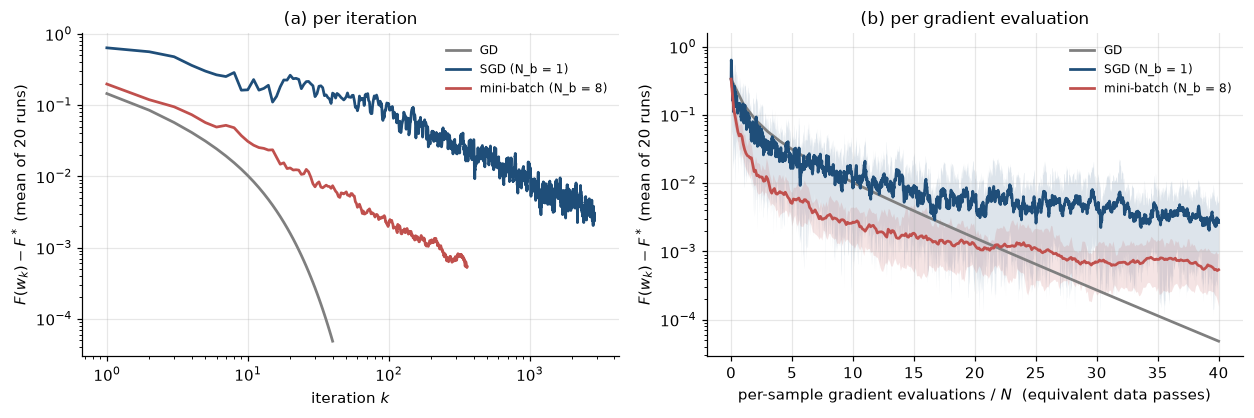

In [4]:
w0 = np.zeros(3)                                                          # the same initialization for all methods
epochs = 40
eta_gd = 1 / L_bound
schedule = lambda B: (lambda k: (1 / L_bound) / (1 + k * B / N))          # eta_k = (1/L) / (1 + k N_b / N)

methods = {"GD": (N, None), "SGD (N_b = 1)": (1, schedule(1)), "mini-batch (N_b = 8)": (8, schedule(8))}
mean_gap, evals, single_run, band = {}, {}, {}, {}
for name, (B, eta) in methods.items():
    if name == "GD":                                                      # deterministic: one run
        it, ev = minibatch_sgd(batch_grad, w0, N, eta_gd, epochs, sampling="full")
        mean_gap[name], evals[name] = np.array([F(w) for w in it]) - F_star, ev
        continue
    curves = []
    for r in range(20):                                                   # 20 independent runs
        it, ev = minibatch_sgd(batch_grad, w0, N, eta, epochs * N // B, rng, batch_size=B)
        curves.append(np.array([F(w) for w in it]) - F_star)
    mean_gap[name], evals[name], single_run[name] = np.mean(curves, axis=0), ev, curves[0]
    band[name] = np.quantile(curves, [0.1, 0.9], axis=0)                  # spread over the 20 runs

checkpoints = [1, 2, 5, 10, 40]                                            # in epochs
print("mean of F(w) - F* after", checkpoints, "epochs (20 runs for the stochastic methods):")
for name, (B, _) in methods.items():
    values = [mean_gap[name][e * N // B] for e in checkpoints]
    print(f"  {name:22s}", np.array2string(np.array(values), formatter={"float_kind": lambda v: f"{v:.1e}"}))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.9))
for name, color in zip(methods, (COLORS["reference"], COLORS["state"], COLORS["control"])):
    ax1.loglog(np.arange(1, len(mean_gap[name])), mean_gap[name][1:], color=color, label=name)
    ax2.semilogy(evals[name] / N, mean_gap[name], color=color, label=name)
for name, color in (("SGD (N_b = 1)", COLORS["state"]), ("mini-batch (N_b = 8)", COLORS["control"])):
    ax2.fill_between(evals[name] / N, band[name][0], band[name][1], color=color, alpha=0.15, lw=0)
ax1.set_xlabel("iteration $k$"); ax1.set_ylabel(r"$F(w_k)-F^*$ (mean of 20 runs)"); ax1.set_title("(a) per iteration")
ax1.legend(fontsize=8)
ax2.set_xlabel("per-sample gradient evaluations / $N$  (equivalent data passes)"); ax2.set_ylabel(r"$F(w_k)-F^*$ (mean of 20 runs)")
ax2.set_title("(b) per gradient evaluation"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 2.** Regularized logistic regression on E6 (72 training samples), from $w=0$: GD with $\eta=1/L$, SGD and mini-batch ($N_b=8$) with $\eta_k=(1/L)/(1+kN_b/N)$, sampling with replacement; stochastic curves are means over 20 runs. *(a)* Gap against iterations. *(b)* Gap against per-sample gradient evaluations divided by $N$ ("equivalent data passes": with replacement, a pass need not visit every sample), with the 10–90% band of the 20 runs.

*Interpretation (answer to the prediction).* *Per iteration* (a), GD is ahead: each of its steps uses all 72 gradients. *Per gradient evaluation* (b), after one pass GD has taken one step, the mini-batch method 9 and SGD 72; the printed averages put the mini-batch method about four times below GD, and SGD only slightly below it, because its first steps of size $1/L$ are very noisy. Later GD's linear convergence takes over: after 40 passes it is the most accurate here, and SGD the least. This is the shape of the slides' comparison (p. 277), which an iteration count alone would hide. The steps were fixed in advance; other schedules change the numbers, not the need to count evaluations. The advantage claimed on p. 271 is asymptotic, for large $N$; with $N=72$ it barely shows.

## 7. Constant steps, the noise floor, and Robbins–Monro
`CORE`

With a constant step, Theorem 1 only gives an upper bound with a term proportional to $\eta$; it does not prove that the error stalls. We now *observe* it, on a problem where $\sigma^2(w^*)>0$: at the minimizer the individual gradients do not vanish (Figure 1). The problem is genuinely stochastic at its solution. For a problem where every $\nabla f_i(w^*)=0$ (an *interpolating* problem, where one parameter fits all samples exactly) the floor would disappear; that special case must not be generalized.

We run SGD with two constant steps and with the Robbins–Monro schedule of §6, for 100 epochs, and average $F(w_k)-F^*$ over 10 runs, evaluated at the end of each epoch.

> **Predict.** If the constant step is divided by four, by roughly what factor does the floor go down? Does the decreasing schedule have a floor?

constant $\eta=1/L$                      mean gap over epochs 51-100: 2.68e-01
constant $\eta=1/(4L)$                   mean gap over epochs 51-100: 4.13e-02
Robbins–Monro $\eta_k=(1/L)/(1+k/N)$     mean gap over epochs 51-100: 1.78e-03


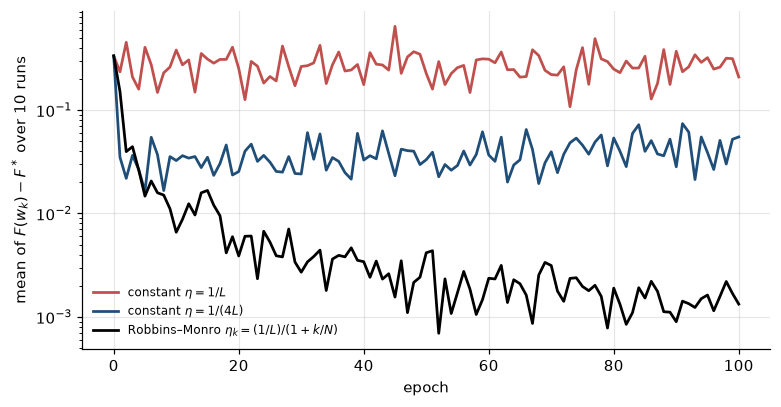

In [5]:
n_runs, n_epochs = 10, 100
settings = {r"constant $\eta=1/L$": eta_gd, r"constant $\eta=1/(4L)$": eta_gd / 4,
            r"Robbins–Monro $\eta_k=(1/L)/(1+k/N)$": schedule(1)}
floor_curves = {}
for name, eta in settings.items():
    curves = []
    for _ in range(n_runs):
        it, ev = minibatch_sgd(batch_grad, w0, N, eta, n_epochs * N, rng, batch_size=1)
        curves.append([F(w) - F_star for w in it[::N]])                    # once per epoch
    floor_curves[name] = np.mean(curves, axis=0)
for name, curve in floor_curves.items():
    print(f"{name:40s} mean gap over epochs 51-100: {curve[51:].mean():.2e}")

fig, ax = plt.subplots(figsize=(7.2, 3.8))
for (name, curve), color in zip(floor_curves.items(), (COLORS["control"], COLORS["state"], "black")):
    ax.semilogy(np.arange(len(curve)), curve, color=color, label=name)
ax.set_xlabel("epoch"); ax.set_ylabel(r"mean of $F(w_k)-F^*$ over 10 runs"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 3.** SGD on the E6 logistic problem with a constant step $\eta=1/L$, a constant step $\eta=1/(4L)$, and the Robbins–Monro schedule $\eta_k=(1/L)/(1+k/N)$: optimality gap at the end of each epoch, averaged over 10 runs.

*Interpretation (answer to the prediction).* Both constant steps stall: after a fast initial decrease, the average gap stays at a level that no longer improves. Dividing the step by four lowers the printed floor by a factor of about seven: the floor shrinks with $\eta$, consistently with the bound of §5, which is only an upper estimate: it neither proves the floor nor gives the factor. The decreasing schedule has no floor and keeps improving, slowly. This is the trade-off behind every learning-rate schedule: large steps make fast early progress and a high floor, small steps make slow progress and a low floor.

## 8. Early stopping: choosing *when to stop* on the validation set
`CORE`

The slides recommend: "use a validation set to indicate **early stopping**" (p. 273). Training time is then a hyperparameter, exactly like the degree in notebook 09, and the same protocol applies: the stopping time is chosen on the validation set only, and the final evaluation uses data on which no decision depends.

**The experiment.** On E9, with the split of notebook 09, two over-parametrized models are trained by gradient descent from $w=0$ on the training MSE, with $\eta=1/L$: **(P)** a Legendre polynomial of degree 40 and **(G)** a combination of 41 Gaussian bumps $e^{-((x-c_j)/0.1)^2}$ with equally spaced centres; both have 41 coefficients for 36 training samples. For each, we record training and validation errors at 120 logarithmically spaced iterations up to $10^5$, and stop at the recorded iteration with the smallest validation error.

**An honest note on this laboratory.** It was first written with (P) alone. Its validation-selected model had validation MSE $0.098$, but MSE $1.02$ on the 12-sample E9 test split, because of an oscillation between two training points that no validation sample probed; the laboratory was then changed to (G). That change was a decision informed by the test split, so here the E9 test split is *development data*: we print its values, labelled as such, but they are not a final evaluation. The final evaluation uses a **fresh holdout** of 200 new samples from the same law, generated after both procedures, their hyperparameters and the selection rule had been frozen in writing (`reports/logs/closing_08_11/M1_frozen_protocol.md`), and evaluated once per procedure. Neither procedure is chosen on it.

> **Predict.** As training proceeds, the training error decreases. What does the validation error do, for each model?

P: polynomial, degree 40   stopping time (validation)   1894: training MSE 0.021, validation MSE 0.098;  at 10^5: training 0.0076, validation 4.56
G: 41 Gaussian bumps       stopping time (validation)      9: training MSE 0.065, validation MSE 0.217;  at 10^5: training 0.0206, validation 2.40


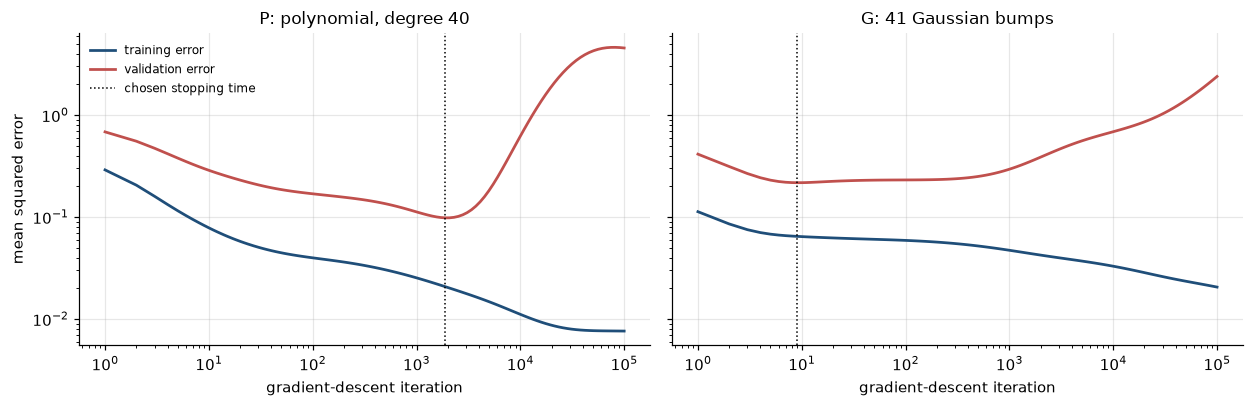

In [6]:
train9, val9, test9 = split9
recorded = np.unique(np.round(np.logspace(0, 5, 120)).astype(int))
procedures = {"P: polynomial, degree 40": lambda x: polynomial_features(x, 40),
              "G: 41 Gaussian bumps": lambda x: gaussian_features(x, np.linspace(-1, 1, 41), 0.1)}


def early_stopping_run(features):
    # GD from w = 0 on the training MSE; the stopping time is chosen on the VALIDATION curve only
    A_tr, A_val, y_tr9, y_val9 = features(x9[train9]), features(x9[val9]), y9[train9], y9[val9]
    grad_ls = lambda w: 2 * A_tr.T @ (A_tr @ w - y_tr9) / len(y_tr9)
    eta_es = 1 / np.linalg.eigvalsh(2 * A_tr.T @ A_tr / len(y_tr9))[-1]  # 1 / L for this quadratic
    w, k, iterates, train_c, val_c = np.zeros(A_tr.shape[1]), 0, [], [], []
    for K in recorded:
        while k < K:
            w = w - eta_es * grad_ls(w)
            k += 1
        iterates.append(w.copy())
        train_c.append(mean_squared_error(A_tr, w, y_tr9))
        val_c.append(mean_squared_error(A_val, w, y_val9))
    stop = int(np.argmin(val_c))
    return {"train": np.array(train_c), "val": np.array(val_c), "stop_index": stop,
            "stopping_time": int(recorded[stop]), "w": iterates[stop]}


es = {name: early_stopping_run(features) for name, features in procedures.items()}
for name, r in es.items():
    print(f"{name:26s} stopping time (validation) {r['stopping_time']:6d}: training MSE {r['train'][r['stop_index']]:.3f}, "
          f"validation MSE {r['val'][r['stop_index']]:.3f};  at 10^5: training {r['train'][-1]:.4f}, validation {r['val'][-1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), sharey=True)
for ax, (name, r) in zip(axes, es.items()):
    ax.loglog(recorded, r["train"], color=COLORS["state"], label="training error")
    ax.loglog(recorded, r["val"], color=COLORS["control"], label="validation error")
    ax.axvline(r["stopping_time"], color="black", ls=":", lw=1, label="chosen stopping time")
    ax.set_title(name); ax.set_xlabel("gradient-descent iteration")
axes[0].set_ylabel("mean squared error"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 4.** Gradient descent on the E9 training data for two over-parametrized models with 41 coefficients each, from $w=0$: (P) a degree-40 polynomial and (G) 41 Gaussian bumps. Training and validation errors against the iteration (logarithmic axes), and the stopping time chosen on each validation curve. No test or holdout error is plotted: none plays a role in the choice.

*Interpretation (answer to the prediction).* For both models the training error decreases monotonically, while the validation error first decreases and then rises by an order of magnitude or more: gradient descent fits the smooth part of the data first and the noise later, so *training time acts like model complexity*. The stopping time is chosen at the validation minimum, restricted to the 120 recorded iterations. How good the stopped models are on new data is a separate question, answered once below on the fresh holdout. Twelve validation samples cannot certify a model everywhere on $[-1,1]$: this is exactly what happened to (P) when the laboratory was designed.

In [7]:
# (1) Development data, ALREADY EXPOSED during the design of this laboratory: the 12-sample E9 test split.
dev_test_mse = {name: mean_squared_error(procedures[name](x9[test9]), r["w"], y9[test9]) for name, r in es.items()}
# (2) Final evaluation, protocol frozen before generation: a fresh holdout of 200 samples, once per procedure.
holdout_rng = rng.spawn(1)[0]                  # first child of seed 0: independent of every draw made above
x_new, y_new = regression_E9(holdout_rng, n=200)
holdout_mse = {name: mean_squared_error(procedures[name](x_new), r["w"], y_new) for name, r in es.items()}
protocol_es = {"train indices": train9, "validation indices": val9, "development test indices (already exposed)": test9,
               "selected stopping times": {name: r["stopping_time"] for name, r in es.items()},
               "fresh holdout": "regression_E9(rng.spawn(1)[0], n=200)", "final holdout MSE": holdout_mse}
for name in es:
    print(f"{name:26s} development test split (12, already exposed): {dev_test_mse[name]:.3f};   "
          f"fresh holdout (200, single evaluation): {holdout_mse[name]:.3f}")

P: polynomial, degree 40   development test split (12, already exposed): 1.020;   fresh holdout (200, single evaluation): 0.399
G: 41 Gaussian bumps       development test split (12, already exposed): 0.119;   fresh holdout (200, single evaluation): 0.118


**Reading the final evaluation.** On the fresh holdout (printed), the stopped polynomial (P) has an error about three times that of the stopped bumps (G), and G's error is close to that of the polynomial selected in notebook 09. The 12-sample development split had exaggerated P's failure (MSE $1.02$) but not invented it. These numbers were computed once, after both procedures were frozen; neither is chosen on them. The lesson that survives is that twelve validation samples did not detect P's weakness: a stopping rule is only as reliable as the validation data behind it.

## 9. Control ↔ ML
`CORE`

- **GD is explicit Euler.** **DIRECT CONNECTION** (notebook 06): GD discretizes the gradient flow $w'=-\nabla F(w)$ in the time $\tau=k\eta$.
- **SGD as a noisy Euler scheme.** **MATHEMATICAL ANALOGY** *(a proposed reading)*. With $g_k=\nabla F(w_k)+\xi_k$, $\mathbb E\xi_k=0$, SGD is the Euler scheme perturbed by $-\eta_k\xi_k$; the perturbations accumulate like a random walk with variance of order $\sum\eta_k^2\sigma_g^2$, which is why $\sum\eta_k^2<\infty$ appears in Theorem 1.
- **Memory and damping.** **FORWARD CONNECTION.** [Notebook 11](11_optimization_algorithms_ml.ipynb) adds memory to the iteration: a discretized damped oscillator, the system of notebook 05.
- **Training a controlled dynamics.** **FORWARD CONNECTION.** In [notebook 13](13_resnets_neural_odes.ipynb), the parameters of a residual network are controls, and training is this notebook's method applied to an optimal control problem.

## 10. Proofs: Theorem 1 and the finite-population correction
`DEEPER LOOK`

**Proof of Theorem 1.** Write $g_k=\nabla f_{i_k}(w_k)$ and $\mathbb E_k=\mathbb E[\,\cdot\mid w_k]$.

*Step 1 (descent lemma).* Since $\nabla F$ is $L$-Lipschitz, $F(v)\le F(w)+\langle\nabla F(w),v-w\rangle+\frac L2|v-w|^2$ for all $v,w$ (integrate $\frac{d}{dt}F(w+t(v-w))$ and use (A2)). With $v=w_{k+1}=w_k-\eta_kg_k$:
$$
F(w_{k+1})\le F(w_k)-\eta_k\langle\nabla F(w_k),g_k\rangle+\tfrac L2\eta_k^2|g_k|^2 .
$$
*Step 2 (conditional expectation).* By (A5), $\mathbb E_kg_k=\nabla F(w_k)$ (§3). Expanding the square, $\mathbb E_k|g_k|^2=|\nabla F(w_k)|^2+\mathbb E_k|g_k-\nabla F(w_k)|^2\le|\nabla F(w_k)|^2+\sigma_g^2$ by (A3). Hence
$$
\mathbb E_kF(w_{k+1})\le F(w_k)-\eta_k\big(1-\tfrac L2\eta_k\big)|\nabla F(w_k)|^2+\tfrac L2\eta_k^2\sigma_g^2 .
$$
By (A4), $1-\frac L2\eta_k\ge1-\frac L2\bar\eta=c>0$, which gives the first inequality of (i); the second follows from $c\ge0$ and $\frac L2\eta_k<1$.

*Step 3 (telescoping).* Take total expectations and sum over $k=1,\dots,K$; the values $\mathbb EF(w_k)$ telescope, and $\mathbb EF(w_{K+1})\ge F^*$ by (A1):
$$
c\sum_{k=1}^K\eta_k\,\mathbb E|\nabla F(w_k)|^2\le F(w_1)-F^*+\tfrac L2\sigma_g^2\sum_{k=1}^K\eta_k^2 .
$$
Dividing by $c\,S_K$ gives the weighted-average bound of (ii), and a weighted average is at least the minimum, which gives the first inequality of (ii). Under the Robbins–Monro conditions the numerator stays bounded and the denominator diverges, which is (iii). Finally $\mathbb E\min_k|\nabla F(w_k)|^2\le\min_k\mathbb E|\nabla F(w_k)|^2$, since the minimum is below each term. $\square$

Where each hypothesis entered: (A2) in Step 1, (A3) and (A5) in Step 2, (A4) to get one constant $c$ for all $k$, (A1) in Step 3. If only $\eta_k<2/L$ is assumed, as on p. 265, the factors $1-\frac L2\eta_k$ could approach zero along a general schedule. Under the Robbins–Monro conditions this cannot happen: $\eta_k\to0$, so only finitely many steps exceed any given level, and their maximum is below $2/L$; hence $\sup_k\eta_k<2/L$ holds automatically.

**An almost-sure consequence (not needed in the CORE).** Under the Robbins–Monro conditions, Step 3 gives $\sum_k\eta_k\,\mathbb E|\nabla F(w_k)|^2<\infty$. By Tonelli's theorem $\mathbb E\sum_k\eta_k|\nabla F(w_k)|^2<\infty$, so $\sum_k\eta_k|\nabla F(w_k)|^2<\infty$ almost surely; since $\sum_k\eta_k=\infty$, this forces $\liminf_k|\nabla F(w_k)|=0$ almost surely. This is still not a statement about the last iterate.

**The finite-population correction.** Let $a_i=\nabla f_i(w)-\nabla F(w)$, so $\sum_ia_i=0$ and $\frac1N\sum_i|a_i|^2=\sigma^2(w)$. For a uniformly chosen subset $I$ of size $N_b$, each index belongs to $I$ with probability $N_b/N$, and each pair $i\ne j$ with probability $\frac{N_b(N_b-1)}{N(N-1)}$. Then
$$
\mathbb E\Big|\sum_{i\in I}a_i\Big|^2=\frac{N_b}N\sum_i|a_i|^2+\frac{N_b(N_b-1)}{N(N-1)}\sum_{i\ne j}\langle a_i,a_j\rangle .
$$
Since $\sum_{i\ne j}\langle a_i,a_j\rangle=\big|\sum_ia_i\big|^2-\sum_i|a_i|^2=-N\sigma^2(w)$, the right side equals $N_b\sigma^2(w)\big(1-\frac{N_b-1}{N-1}\big)=N_b\sigma^2(w)\frac{N-N_b}{N-1}$. Dividing by $N_b^2$ gives Proposition 1 without replacement. The test file of the shared code checks both formulas by exhaustive enumeration on a small example. $\square$

## 11. Does noise help generalization?
`RESEARCH WINDOW`

The slides add several remarks that are not theorems, and it is important to read them as such.

- "SGD is less prone to overfitting because the data are chosen randomly" (p. 273). Figure 4 shows overfitting by *deterministic* GD and its cure by early stopping; whether stochasticity itself regularizes is a separate claim.
- Algorithms that converge to "high precision" may converge to **sharp** minima, which would generalize worse than **flat** ones (pp. 306–307).
- "Generalization and overfitting problems are poorly understood but noise helps"; very precise methods (variance reduction, second-order methods) are rarely used in deep learning (p. 308).

These statements describe an active research question, the *implicit regularization* of training algorithms: among the many minimizers of an over-parametrized loss, which one does a given algorithm find, and why would it generalize? Precise answers exist for special cases (for instance, gradient descent from zero on least squares converges to the minimum-norm interpolant); for neural networks the question is open, and the flat/sharp picture is a heuristic with known counterexamples. In this course they remain hypotheses, to be tested with the protocol of notebook 09.

## 12. Common misconceptions
`CORE`

**"SGD is faster than GD."** It depends on the unit and the accuracy. In Figure 2, GD was ahead per iteration throughout; per gradient evaluation the mini-batch method led early and GD at high accuracy. State the cost unit and the accuracy.

**"SGD converges to the minimizer with any small constant step."** In the examples it stalls at a level that shrinks with the step (Figure 3; exactly computed for the quadratic of Exercise 2), because the sample gradients do not vanish at the solution.

**"The theorem shows that the gradient of the last iterate goes to zero."** It bounds the minimum and a weighted average of $\mathbb E|\nabla F(w_k)|^2$ (Theorem 1), not the last iterate.

**"Without replacement is just a detail."** It changes the variance of mini-batches (Proposition 1) and breaks the conditional unbiasedness used in the classical proof.

**"The best stopping time is where the test error is smallest."** That uses the test set for a choice. Stop on the validation curve; evaluate the test set once (§8).

## 13. What you should remember
`CORE`

1. Training minimizes a finite sum $F=\frac1N\sum_if_i$. Cost unit: one per-sample gradient; GD costs $N$ per step, SGD $1$, mini-batch $N_b$.
2. SGD uses $g_k=\nabla f_{i_k}(w_k)$, with $\mathbb E[g_k\mid w_k]=\nabla F(w_k)$ for uniform sampling with replacement.
3. Mini-batch variance: $\sigma^2/N_b$ with replacement, $\frac{\sigma^2}{N_b}\frac{N-N_b}{N-1}$ without.
4. Theorem (p. 265, audited): under (A1)–(A5), $\min_{k\le K}\mathbb E|\nabla F(w_k)|^2\le\dfrac{F(w_1)-F^*+\frac L2\sigma_g^2\sum\eta_k^2}{c\sum\eta_k}\to0$ when $\sum\eta_k=\infty$, $\sum\eta_k^2<\infty$.
5. Constant steps: the bound keeps a term proportional to $\eta$; in the examples the error stalls at a level that shrinks with $\eta$, because $\sigma^2(w^*)>0$.
6. Compare methods by gradient evaluations as well as iterations, from the same initialization, on the same objective.
7. Early stopping chooses the training time on the validation set; the test set is used once, afterwards.

## 14. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (why unbiasedness matters)** · `FIRST PASS`. (a) Suppose SGD draws index $i$ with probability $p_i>0$ instead of $1/N$. Show that $\nabla f_i$ is then a *biased* estimate of $\nabla F$, and that $\frac{1}{Np_i}\nabla f_i$ is unbiased. (b) What does biased SGD converge to, when it converges? Consider $N=2$, $f_1(w)=\frac12(w-1)^2$, $f_2(w)=\frac12(w+1)^2$, $p_1=0.9$, and the fixed points of the expected update. (c) Which step of the proof of Theorem 1 fails for a biased estimate?

**Exercise 2 ★★ (the noise floor, exactly)** · `FIRST PASS`. Let $f_i(w)=\frac12(w-c_i)^2$ in one dimension, with numbers $c_1,\dots,c_N$ that are not all equal, mean $\bar c$ and variance $s^2=\frac1N\sum_i(c_i-\bar c)^2>0$. (a) Show that $F$ is minimized at $w^*=\bar c$, that $L=1$, and that $\sigma^2(w^*)=s^2$. (b) For SGD with constant step $0<\eta<2$ and sampling with replacement, let $e_k=\mathbb E(w_k-w^*)^2$. Show that $e_{k+1}=(1-\eta)^2e_k+\eta^2s^2$, and deduce that $e_k\to\dfrac{\eta\,s^2}{2-\eta}$. (c) Interpret: what happens as $\eta\to0$, and for $s=0$? Check the limit numerically for $c=(0,1,2,3,4)$ and $\eta=0.1$.

**Exercise 3 ★★ (constants in the theorem)** · `STANDARD`. (a) From the telescoped inequality of §10 (Step 3) with a constant step $\eta\le\bar\eta<2/L$, derive the estimate of §5 for $\frac1K\sum_{k\le K}\mathbb E|\nabla F(w_k)|^2$. (b) For a fixed budget of $K$ steps, choose $\eta$ to minimize the right-hand side, ignoring the constraint $\eta\le\bar\eta$, and show that the bound then decays like $K^{-1/2}$. (c) Explain why this does not contradict the faster convergence of GD in Figure 2.

**Exercise 4 ★★ (which schedules are Robbins–Monro?)** · `STANDARD`. For each schedule decide whether $\sum\eta_k=\infty$ and $\sum\eta_k^2<\infty$: (a) $\eta_k=\eta_0/k$; (b) $\eta_k=\eta_0/\sqrt k$; (c) $\eta_k=\eta_0/k^2$; (d) $\eta_k=\eta_0/(k\log(k+1))$; (e) $\eta_k=\eta_0$. For (b), which fails the second condition, show that the bound (ii) still tends to zero, like $(\log K)/\sqrt K$. What does (c) do in practice?

**Exercise 5 ★★★ (with or without replacement?)** · `ADVANCED`. Repeat the SGD run of §6 ($N_b=1$, the same schedule and budget) with `sampling="epoch"` (without replacement, reshuffling every epoch), for 20 runs each, and compare the mean gap $F(w)-F^*$ after 1, 5 and 40 epochs with sampling with replacement. Which converges faster on this problem? Relate your answer to Proposition 1 and to the loss of conditional unbiasedness discussed in §3.

In [8]:
# TODO: student exercise (Exercise 5)
# Use minibatch_sgd(batch_grad, w0, N, schedule(1), 40 * N, rng, batch_size=1, sampling="epoch")
# and the same call with sampling="with"; average F(w) - F_star over 20 runs at epochs 1, 5, 40.

def mean_gaps(sampling):
    ...  # your code here
    return None

**Exercise 6 ★★★ (batch size and the floor)** · `ADVANCED`. Run mini-batch SGD with the *constant* step $\eta=1/L$ and batch sizes $N_b=1,4,16$ for 60 epochs (sampling with replacement), and estimate the floor of each by averaging $F(w)-F^*$ over the last 30 epochs and 10 runs. How does the floor depend on $N_b$ at a fixed step? Compare with $\sigma_g^2\propto1/N_b$ in Theorem 1, and discuss what changes if the *budget of gradient evaluations*, rather than the number of steps, is fixed.

## Where are we going?
`CORE`

GD and SGD follow the current gradient only; they have no memory. On ill-conditioned problems they zigzag across narrow valleys (notebook 06), and with noise they need decreasing steps. [Notebook 11](11_optimization_algorithms_ml.ipynb) adds two mechanisms: **memory**, through momentum, whose continuous model is the damped oscillator of notebook 05; and **adaptivity**, through per-coordinate step sizes (AdaGrad, RMSProp, Adam). The comparisons there follow the rules of this notebook: same objective, same initialization, gradient-evaluation counts, and validation-only choices.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Finite sums | 252–255, 257, 277 | Training as optimization; finite sum; linear and logistic regression; nonconvexity of NN losses; regularized logistic regression |
| §2 Gradient descent | 262–263 | Full-batch GD; challenges for large $N$ |
| §3 SGD | 264 | Uniform index; with and without replacement; epoch; unbiased estimate |
| §4 Mini-batch | 275 | Mini-batch update; variance reduction; batch sizes; matrix operations |
| §5 Theorem | 265–268, 271 | Assumptions 1–4; noise level; Robbins–Monro conditions; proof; complexity comparison |
| §6 Comparison | 276–277 | Loss vs iterations and vs flops |
| §8 Early stopping | 273 | Validation set to indicate early stopping |
| §11 Research window | 273, 306–308 | Overfitting and SGD; flat vs sharp minima; "noise helps" |

The source-map rows also record the pedagogical additions (the cost unit, Proposition 1 and Figure 1, the audit table and the added hypotheses (A4)–(A5) of Theorem 1, the noise-floor consequence, the laboratories and Figures 2–4, the protocol record, the SGD-as-noisy-Euler reading) and the corrections (p. 265: conditional expectation, uniform step bound, minimum of expectations; p. 268: $F(\theta_1)$; p. 271: missing strong-convexity assumptions).